# Clean Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

df = pd.read_csv(r"D:\Thesis\mentaldata\mentaldataset.csv")

print(df.shape)
df.head()

(124, 27)


,Timestamp,Choose your gender,Age,Your current year of Study,Living Situation,Dietary Habit,Do you use or have you ever used Nicotine?,Part-time working hours per week,Academic Pressure [I feel exhausted by the amount of coursework I have.],Academic Pressure [I often feel stressed before or during exams.],...,Study Satisfaction [I am not satisfied with what I am learning in my program.],Study Satisfaction [I often regret choosing my current major/program.],Study Satisfaction [I do not feel fully satisfied with my experience at this university],Sleep Duration(hours),Do you have Anxiety?,Do you have Depression?,"Have you had problems with Short-term Memory (e.g., forgetting recent conversations, misplacing items, or what you just studied)?",Family history of mental illness,Self-harm or Suicidal Ideation (last 12 months),"Have you ever seriously considered leaving university (e.g., taking a leave of absence for ≥1 semester or permanently withdrawing)?"
0,11/24/2025 1:41:28,Male,20-22,4,With parents/relatives,Moderate,No,NaN,Agree,Strongly agree,...,Disagree,Disagree,Neutral,5–6,Yes — suspected/undocumented,No,4,No,No,No
1,11/24/2025 10:25:06,Male,20-22,4,With parents/relatives,Moderate,No,1–8,Neutral,Agree,...,Strongly disagree,Disagree,Neutral,7–8,No,No,4,Unsure,No,No
2,11/24/2025 10:27:34,Male,20-22,4,With parents/relatives,Moderate,No,NaN,Neutral,Neutral,...,Agree,Disagree,Neutral,>8,No,No,4,Unsure,No,No
3,11/24/2025 10:30:22,Male,20-22,4,With parents/relatives,Healthy (mostly balanced meals),No,20+,Disagree,Disagree,...,Disagree,Disagree,Disagree,7–8,No,No,3,No,No,No
4,11/24/2025 10:34:55,Male,20-22,4,With parents/relatives,Moderate,No,1–8,Neutral,Agree,...,Strongly disagree,Strongly disagree,Neutral,7–8,Yes — suspected/undocumented,Yes — suspected/undocumented,2,Unsure,No,No


In [2]:
df.columns = df.columns.str.strip()
df_clean = df.copy()

df_clean = df_clean.drop(columns=['Timestamp'])
df_clean = df_clean.rename(columns={
    "Choose your gender": "gender",
    "Age": "age",
    "Your current year of Study": "study_year",
    "Living Situation": "living_situation",
    "Dietary Habit": "dietary_habit",
    "Do you use or have you ever used Nicotine?": "nicotine_use",
    "Part-time working hours per week": "work_hours",

    # Academic pressure
    "Academic Pressure   [I feel exhausted by the amount of coursework I have.]": "AP1",
    "Academic Pressure   [I often feel stressed before or during exams.]": "AP2",
    "Academic Pressure   [I worry that I will not meet my academic expectations.]": "AP3",
    "Academic Pressure   [I feel I need to reduce my sleep and entertainment time to keep up with my studies.]": "AP4",

    # Financial stress
    "Financial Stress   [I worry about having enough money to cover my basic living expenses.]": "FS1",
    "Financial Stress   [My family has difficulty affording my tuition and university fees.]": "FS2",
    "Financial Stress   [My family is currently facing financial difficulties.]": "FS3",

    # Family pressure
    "Family Pressure [My family has very high expectations for my academic performance.]": "FP1",
    "Family Pressure [I feel stressed because my grades might disappoint my family.]": "FP2",

    # Study satisfaction
    "Study Satisfaction   [I am not satisfied with what I am learning in my program.]": "SS1",
    "Study Satisfaction   [I often regret choosing my current major/program.]": "SS2",
    "Study Satisfaction   [I do not feel fully satisfied with my experience at this university]": "SS3",

    "Sleep Duration(hours)": "sleep_duration",
    "Do you have Anxiety?": "anxiety",
    "Do you have Depression?": "depression",
    "Have you had problems with Short-term Memory (e.g., forgetting recent conversations, misplacing items, or what you just studied)?": "short_term_memory",
    "Family history of mental illness": "family_history",
    "Self-harm or Suicidal Ideation (last 12 months)": "self_harm",

    "Have you ever seriously considered leaving university (e.g., taking a leave of absence for ≥1 semester or permanently withdrawing)?": "intent_to_quit",


})


df_clean.columns
df_clean.head()

,gender,age,study_year,living_situation,dietary_habit,nicotine_use,work_hours,AP1,AP2,AP3,...,SS1,SS2,SS3,sleep_duration,anxiety,depression,short_term_memory,family_history,self_harm,intent_to_quit
0,Male,20-22,4,With parents/relatives,Moderate,No,NaN,Agree,Strongly agree,Agree,...,Disagree,Disagree,Neutral,5–6,Yes — suspected/undocumented,No,4,No,No,No
1,Male,20-22,4,With parents/relatives,Moderate,No,1–8,Neutral,Agree,Strongly agree,...,Strongly disagree,Disagree,Neutral,7–8,No,No,4,Unsure,No,No
2,Male,20-22,4,With parents/relatives,Moderate,No,NaN,Neutral,Neutral,Neutral,...,Agree,Disagree,Neutral,>8,No,No,4,Unsure,No,No
3,Male,20-22,4,With parents/relatives,Healthy (mostly balanced meals),No,20+,Disagree,Disagree,Disagree,...,Disagree,Disagree,Disagree,7–8,No,No,3,No,No,No
4,Male,20-22,4,With parents/relatives,Moderate,No,1–8,Neutral,Agree,Agree,...,Strongly disagree,Strongly disagree,Neutral,7–8,Yes — suspected/undocumented,Yes — suspected/undocumented,2,Unsure,No,No


In [3]:
#Nicotine
df_clean["nicotine_use"] = df_clean["nicotine_use"].replace(
    {"Yes": 5, "No": 1}
).astype("Int64")

# Dietary Habit
for col in ["dietary_habit"]:
    df_clean[col] = df_clean[col].replace({"Unhealthy (frequent fast/processed foods)": 5, "Healthy (mostly balanced meals)": 1, "Moderate": 3}).astype("Int64")

# Likert Column
likert_cols = [
    "AP1", "AP2", "AP3", "AP4",
    "FS1", "FS2", "FS3",
    "FP1", "FP2",
    "SS1", "SS2", "SS3"
]

likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}

df_clean[likert_cols] = df_clean[likert_cols].replace(likert_map).astype("Int64")

# Work Hours
work_map = {
    "1–8": 2,
    "9–14": 3,
    "15–19": 4,
    "20+": 5
}

df_clean["work_hours"] = df_clean["work_hours"].replace(work_map)

df_clean["work_hours"] = df_clean["work_hours"].fillna(1).astype("Int64")

# Anxiety & Depression
for col in ["anxiety", "depression"]:
    df_clean[col] = df_clean[col].replace({"Yes — diagnosed by a professional": 5, "No": 1, "Yes — suspected/undocumented": 5}).astype("Int64")

# sleep_duration
for col in ["sleep_duration"]:
    df_clean[col] = df_clean[col].replace({"<5": 5, ">8": 5, "7–8": 1,"5–6":3}).astype("Int64")

# Self Harm
for col in ["self_harm"]:
    df_clean[col] = df_clean[col].replace({"Yes": 5, "No": 1}).astype("Int64")

# Family History
for col in ["family_history"]:
    df_clean[col] = df_clean[col].replace({"Yes": 5, "No": 1, "Unsure": 3}).astype("Int64")

# Intent to quit
for col in ["intent_to_quit"]:
    df_clean[col] = df_clean[col].replace({"Yes": 5, "No": 1, ">= 1 semester" : 3}).astype("Int64")

C:\Users\daoth\AppData\Local\Temp\ipykernel_18448\2159992253.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean["nicotine_use"] = df_clean["nicotine_use"].replace(
C:\Users\daoth\AppData\Local\Temp\ipykernel_18448\2159992253.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].replace({"Unhealthy (frequent fast/processed foods)": 5, "Healthy (mostly balanced meals)": 1, "Moderate": 3}).astype("Int64")
C:\Users\daoth\AppData\Local\Temp\ipykernel_18448\2159992253.py:26: FutureWarning: Downcasti

In [4]:
import pandas as pd
pd.options.display.max_rows = 50

display(df_clean)

,gender,age,study_year,living_situation,dietary_habit,nicotine_use,work_hours,AP1,AP2,AP3,...,SS1,SS2,SS3,sleep_duration,anxiety,depression,short_term_memory,family_history,self_harm,intent_to_quit
0,Male,20-22,4,With parents/relatives,3,1,1,4,5,4,...,2,2,3,3,5,1,4,1,1,1
1,Male,20-22,4,With parents/relatives,3,1,2,3,4,5,...,1,2,3,1,1,1,4,3,1,1
2,Male,20-22,4,With parents/relatives,3,1,1,3,3,3,...,4,2,3,5,1,1,4,3,1,1
3,Male,20-22,4,With parents/relatives,1,1,5,2,2,2,...,2,2,2,1,1,1,3,1,1,1
4,Male,20-22,4,With parents/relatives,3,1,2,3,4,4,...,1,1,3,1,5,5,2,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Male,20-22,2,With parents/relatives,1,1,2,3,4,4,...,2,3,3,3,5,5,3,1,1,1
120,Male,18-19,2,On-campus Dorm,3,1,1,3,5,5,...,4,2,2,3,5,1,3,1,1,3
121,Male,18-19,2,With parents/relatives,1,1,1,3,3,3,...,3,3,3,1,5,5,3,3,5,5
122,Male,20-22,4,With parents/relatives,3,1,4,3,3,3,...,3,3,3,3,1,1,4,1,1,1


In [5]:
df_clean.to_csv(r"D:\Thesis\mentaldata\mentaldataset_clean.csv", index=False)

In [6]:
import pandas as pd

raw = pd.read_csv(r"D:\Thesis\mentaldata\mentaldataset.csv")
clean = pd.read_csv(r"D:\Thesis\mentaldata\mentaldataset_clean.csv")

# 2. Kiem tra cac cot Likert
likert_cols = [
    "AP1", "AP2", "AP3", "AP4",
    "FS1", "FS2", "FS3",
    "FP1", "FP2",
    "SS1", "SS2", "SS3"
]

# vi tri cac cot goc tu file raw (AP1 bat dau o cot index 8)
likert_raw_idx = [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

for new_col, idx in zip(likert_cols, likert_raw_idx):
    old_col = raw.columns[idx]
    print("\n=== Check", new_col, "===")
    print(pd.crosstab(raw[old_col], clean[new_col], dropna=False))

# 3. Kiem tra nicotine_use
print("\n=== Check nicotine_use ===")
print(pd.crosstab(
    raw["Do you use or have you ever used Nicotine?"],
    clean["nicotine_use"],
    dropna=False
))

# 4. Kiem tra work_hours
print("\n=== Check work_hours ===")
print(pd.crosstab(
    raw["Part-time working hours per week"],
    clean["work_hours"],
    dropna=False
))


=== Check AP1 ===
AP1                                                 1   2   3   4   5
  Academic Pressure   [I feel exhausted by the ...                   
Agree                                               0   0   0  27   0
Disagree                                            0  16   0   0   0
Neutral                                             0   0  59   0   0
Strongly agree                                      0   0   0   0  14
Strongly disagree                                   8   0   0   0   0

=== Check AP2 ===
AP2                                                  1   2   3   4   5
  Academic Pressure   [I often feel stressed be...                    
Agree                                                0   0   0  32   0
Disagree                                             0  10   0   0   0
Neutral                                              0   0  33   0   0
Strongly agree                                       0   0   0   0  38
Strongly disagree                             

In [7]:
df_clean.dtypes

for col in ["gender", "age", "study_year", "work_hours", "nicotine_use", "short_term_memory", "anxiety", "depression","self_harm","intent_to_quit"]:
    print(col)
    print(df_clean[col].value_counts(dropna=False))
    print("-----")

gender
gender
Male                 82
Female               38
Prefer not to say     4
Name: count, dtype: int64
-----
age
age
18-19    58
20-22    45
23+      21
Name: count, dtype: int64
-----
study_year
study_year
4    48
1    44
2    23
3     9
Name: count, dtype: int64
-----
work_hours
work_hours
1    83
2    21
5    11
3     7
4     2
Name: count, dtype: Int64
-----
nicotine_use
nicotine_use
1    114
5     10
Name: count, dtype: Int64
-----
short_term_memory
short_term_memory
4    45
3    36
2    16
5    16
1    11
Name: count, dtype: int64
-----
anxiety
anxiety
5    77
1    47
Name: count, dtype: Int64
-----
depression
depression
1    80
5    44
Name: count, dtype: Int64
-----
self_harm
self_harm
1    104
5     20
Name: count, dtype: Int64
-----
intent_to_quit
intent_to_quit
1    100
5     15
3      9
Name: count, dtype: Int64
-----


In [8]:
df_clean.describe()

,study_year,dietary_habit,nicotine_use,work_hours,AP1,AP2,AP3,AP4,FS1,FS2,...,SS1,SS2,SS3,sleep_duration,anxiety,depression,short_term_memory,family_history,self_harm,intent_to_quit
count,124.000000,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,124.0,...,124.0,124.0,124.0,124.0,124.0,124.0,124.000000,124.0,124.0,124.0
mean,2.491935,2.66129,1.322581,1.685484,3.185484,3.612903,3.959677,3.33871,3.16129,2.806452,...,2.862903,2.33871,2.830645,2.016129,3.483871,2.419355,3.314516,1.919355,1.645161,1.629032
std,1.322082,1.103484,1.093576,1.225521,1.015065,1.247499,1.084999,1.202214,1.143288,1.145351,...,1.142915,1.050645,1.180614,1.182418,1.948457,1.921622,1.128831,1.285294,1.477162,1.358309
min,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.0,1.0
25%,1.000000,2.5,1.0,1.0,3.0,3.0,3.0,2.75,3.0,2.0,...,2.0,2.0,2.0,1.0,1.0,1.0,3.000000,1.0,1.0,1.0
50%,2.000000,3.0,1.0,1.0,3.0,4.0,4.0,3.0,3.0,3.0,...,3.0,2.0,3.0,1.0,5.0,1.0,3.000000,1.0,1.0,1.0
75%,4.000000,3.0,1.0,2.0,4.0,5.0,5.0,4.0,4.0,3.0,...,3.0,3.0,4.0,3.0,5.0,5.0,4.000000,3.0,1.0,1.0
max,4.000000,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.000000,5.0,5.0,5.0


# Test

In [9]:
import numpy as np
import pandas as pd

def cronbach_alpha(df_items: pd.DataFrame) -> float:
    # Loai bo missing trong cac item
    df = df_items.dropna(axis=0, how="any")

    # Chuyen sang numpy array
    item_scores = df.to_numpy(dtype=float)

    # So item
    k = item_scores.shape[1]
    if k < 2:
        raise ValueError("Can it nhat 2 item de tinh Cronbach alpha")

    # Variance tung item
    item_var = item_scores.var(axis=0, ddof=1)

    # Tong diem moi nguoi
    total_scores = item_scores.sum(axis=1)

    # Variance tong diem
    total_var = total_scores.var(ddof=1)

    # Cong thuc Cronbach alpha
    alpha = (k / (k - 1)) * (1 - item_var.sum() / total_var)
    return alpha

In [10]:
import numpy as np
import pandas as pd

# Ham tinh Cronbach alpha cho mot nhom item
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    # Bo cac dong bi missing trong cac item
    df = df_items.dropna(axis=0, how="any")

    # Chuyen sang numpy
    data = df.to_numpy(dtype=float)

    # So item
    k = data.shape[1]
    if k < 2:
        raise ValueError("Need at least 2 items to compute Cronbach alpha")

    # Phuong sai tung item
    item_var = data.var(axis=0, ddof=1)

    # Tong diem moi nguoi
    total_scores = data.sum(axis=1)

    # Phuong sai tong diem
    total_var = total_scores.var(ddof=1)

    # Cong thuc Cronbach alpha
    alpha = (k / (k - 1.0)) * (1.0 - item_var.sum() / total_var)
    return alpha

# Ham tinh item-total correlation (giong bang Item-Total Statistics trong SPSS)
def item_total_correlation(df_items: pd.DataFrame) -> pd.Series:
    df = df_items.dropna(axis=0, how="any")
    corrs = {}

    for col in df.columns:
        # Tong cac item con lai
        total_others = df.drop(columns=[col]).sum(axis=1)
        # Corr giua item va tong cac item con lai
        corrs[col] = df[col].corr(total_others)

    return pd.Series(corrs, name="item_total_corr")


# ---------- KHAI BAO CAC THANG CUA BAN ----------

scales = {
    "AcademicPressure": ["AP1", "AP2", "AP3", "AP4"],
    "FinancialStress": ["FS1", "FS2", "FS3"],
    "FamilyPressure": ["FP1", "FP2"], 
    "StudySatisfaction": ["SS1", "SS2", "SS3"],
    
    
    
}

# ---------- TINH CRONBACH ALPHA CHO TUNG THANG ----------

for scale_name, cols in scales.items():
    items = df_clean[cols]

    alpha = cronbach_alpha(items)
    itc = item_total_correlation(items)

    print(f"Scale: {scale_name}")
    print(f"  Cronbach alpha: {alpha:.3f}")
    print("  Item-total correlation:")
    print(itc)
    print("-" * 40)

Scale: AcademicPressure
  Cronbach alpha: 0.794
  Item-total correlation:
AP1    0.569185
AP2    0.681860
AP3    0.551721
AP4    0.626262
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: FinancialStress
  Cronbach alpha: 0.798
  Item-total correlation:
FS1    0.526883
FS2    0.735016
FS3    0.677030
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: FamilyPressure
  Cronbach alpha: 0.681
  Item-total correlation:
FP1    0.527177
FP2    0.527177
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: StudySatisfaction
  Cronbach alpha: 0.766
  Item-total correlation:
SS1    0.602928
SS2    0.583395
SS3    0.612039
Name: item_total_corr, dtype: float64
----------------------------------------


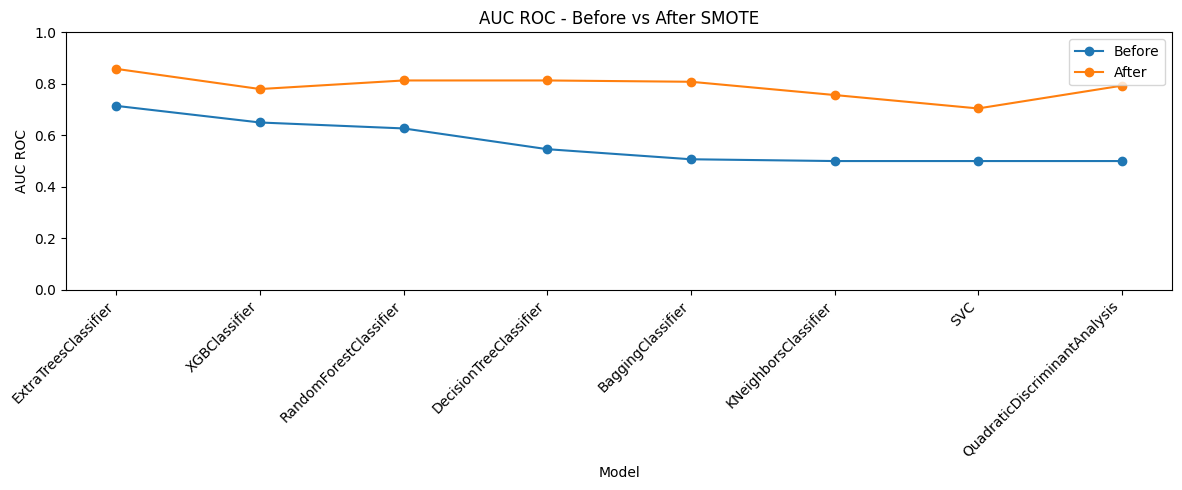

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_auc_roc_before_after_from_csv_paths(
    before_csv_path,
    after_csv_path,
    title="AUC ROC - Before vs After"
):
    b = pd.read_csv(before_csv_path)
    a = pd.read_csv(after_csv_path)

    if "Model" not in b.columns or "AUC ROC" not in b.columns:
        raise ValueError('Before CSV must contain columns: "Model" and "AUC ROC"')
    if "Model" not in a.columns or "AUC ROC" not in a.columns:
        raise ValueError('After CSV must contain columns: "Model" and "AUC ROC"')

    b = b[["Model", "AUC ROC"]].copy()
    a = a[["Model", "AUC ROC"]].copy()

    b["AUC ROC"] = pd.to_numeric(b["AUC ROC"], errors="coerce")
    a["AUC ROC"] = pd.to_numeric(a["AUC ROC"], errors="coerce")

    m = b.merge(a, on="Model", how="inner", suffixes=("_Before", "_After")).dropna()
    m = m.sort_values("AUC ROC_Before", ascending=False).reset_index(drop=True)

    x = np.arange(len(m))

    plt.figure(figsize=(12, 5))
    plt.plot(x, m["AUC ROC_Before"], marker="o", label="Before")
    plt.plot(x, m["AUC ROC_After"], marker="o", label="After")

    plt.xticks(x, m["Model"], rotation=45, ha="right")
    plt.xlabel("Model")
    plt.ylabel("AUC ROC")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --- Run only this block ---
plot_auc_roc_before_after_from_csv_paths(
    before_csv_path=r"D:\Thesis\Before\models_before.csv",
    after_csv_path=r"D:\Thesis\AfterSMOTH\models_after_smote.csv",
    title="AUC ROC - Before vs After SMOTE"
)


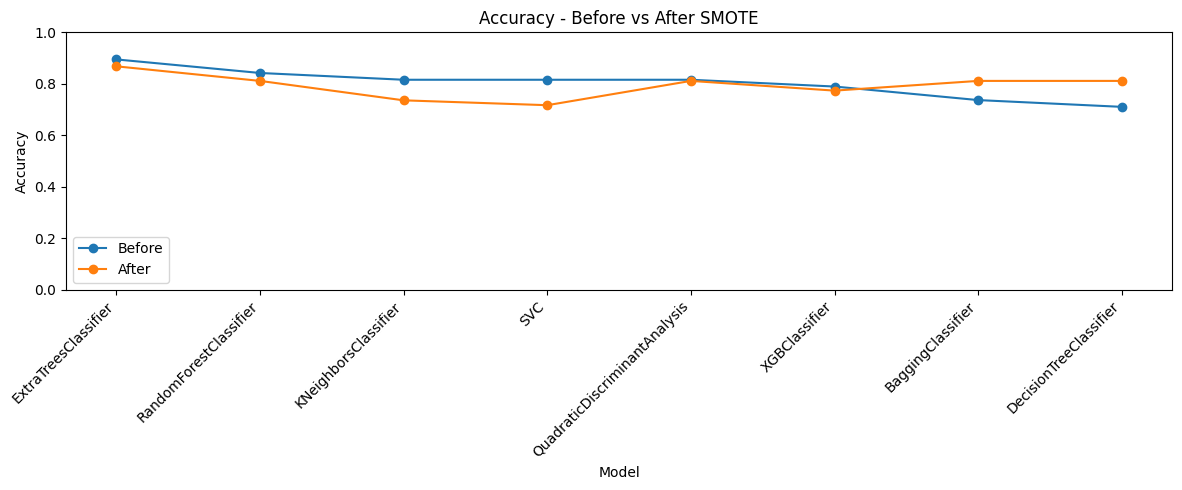

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_accuracy_before_after_from_csv_paths(
    before_csv_path,
    after_csv_path,
    title="Accuracy - Before vs After"
):
    b = pd.read_csv(before_csv_path)
    a = pd.read_csv(after_csv_path)

    if "Model" not in b.columns or "Accuracy" not in b.columns:
        raise ValueError('Before CSV must contain columns: "Model" and "Accuracy"')
    if "Model" not in a.columns or "Accuracy" not in a.columns:
        raise ValueError('After CSV must contain columns: "Model" and "Accuracy"')

    b = b[["Model", "Accuracy"]].copy()
    a = a[["Model", "Accuracy"]].copy()

    b["Accuracy"] = pd.to_numeric(b["Accuracy"], errors="coerce")
    a["Accuracy"] = pd.to_numeric(a["Accuracy"], errors="coerce")

    m = b.merge(a, on="Model", how="inner", suffixes=("_Before", "_After")).dropna()
    m = m.sort_values("Accuracy_Before", ascending=False).reset_index(drop=True)

    x = np.arange(len(m))

    plt.figure(figsize=(12, 5))
    plt.plot(x, m["Accuracy_Before"], marker="o", label="Before")
    plt.plot(x, m["Accuracy_After"], marker="o", label="After")

    plt.xticks(x, m["Model"], rotation=45, ha="right")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --- Run only this block ---
plot_accuracy_before_after_from_csv_paths(
    before_csv_path=r"D:\Thesis\Before\models_before.csv",
    after_csv_path=r"D:\Thesis\AfterSMOTH\models_after_smote.csv",
    title="Accuracy - Before vs After SMOTE"
)
